
# Predicción puntual e intervalos de confianza


In [1]:

# --- Importación de librerías ---
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from IPython.display import display

# Ajustes generales
pd.set_option('display.float_format', '{:,.3f}'.format)


## Cargar datos

In [2]:

# Cargamos nuestros datos
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv("/content/drive/MyDrive/archive/datos_limpios.csv")

print("Dimensiones:", data.shape)
display(data.head())

# Variable dependiente y explicativas
y = data['exam_score']          # Empleo total (objetivo)
X = data.drop(columns=['exam_score'])  # Explicativas
X = sm.add_constant(X)      # Añadimos término independiente


Mounted at /content/drive
Dimensiones: (200, 204)


,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score,student_id_S002,student_id_S003,student_id_S004,student_id_S005,student_id_S006,...,student_id_S191,student_id_S192,student_id_S193,student_id_S194,student_id_S195,student_id_S196,student_id_S197,student_id_S198,student_id_S199,student_id_S200
0,8.000,8.800,72.100,45.000,30.200,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.300,8.600,60.700,55.000,25.000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,4.000,8.200,73.700,86.000,35.800,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3.500,4.800,95.100,66.000,34.000,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,9.100,6.400,89.800,71.000,40.300,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


## Ajuste del modelo OLS

In [3]:

y = data['exam_score']

# Filtrar columnas que sean numéricas y NO booleanas
X = data.drop(columns=['exam_score'])
X = X.select_dtypes(include=['int64','float64'])  # solo numéricos

X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     258.7
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           8.76e-77
Time:                        19:21:40   Log-Likelihood:                -482.21
No. Observations:                 200   AIC:                             974.4
Df Residuals:                     195   BIC:                             990.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.1421      1

## Predicción e intervalos

In [4]:

# Seleccionamos, por ejemplo, las 3 primeras filas para ilustrar
X_pred = X.iloc[:3]
predicciones = modelo.get_prediction(X_pred)
pred_summary = predicciones.summary_frame(alpha=0.05)  # 95%

print("Predicciones y bandas (95%):")
display(pred_summary)

# Columnas:
# - mean: predicción puntual del valor esperado E[Y|X]
# - mean_ci_lower, mean_ci_upper: IC para el valor esperado
# - obs_ci_lower, obs_ci_upper: intervalo de predicción puntual


Predicciones y bandas (95%):


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,34.473,0.418,33.648,35.297,29.023,39.922
1,24.399,0.501,23.411,25.387,18.923,29.876
2,35.122,0.439,34.256,35.988,29.666,40.578


las predicciones las hacemos sobre los coeficiente. multiplicamos x0 por el beta (coeficientes q obtenemos de la tabla anterior).
y0^ = x0t * Β = 60055,660

## Visualización de la incertidumbre

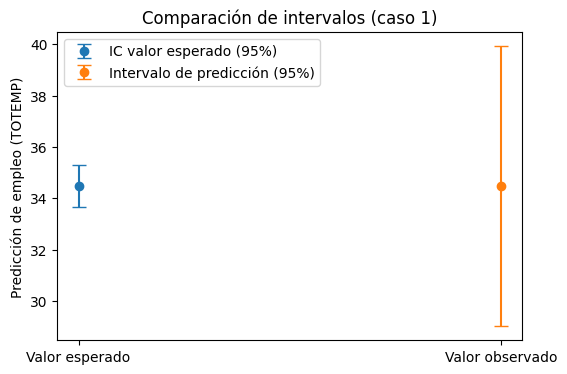

In [5]:

# Elegimos el primer caso para graficar
i = pred_summary.index[0]
mean_pred = pred_summary.loc[i, 'mean']
mean_ci_low = pred_summary.loc[i, 'mean_ci_lower']
mean_ci_up  = pred_summary.loc[i, 'mean_ci_upper']
obs_ci_low  = pred_summary.loc[i, 'obs_ci_lower']
obs_ci_up   = pred_summary.loc[i, 'obs_ci_upper']

plt.figure(figsize=(6,4))

# IC del valor esperado
plt.errorbar(x=['Valor esperado'], y=[mean_pred],
             yerr=[[mean_pred - mean_ci_low], [mean_ci_up - mean_pred]],
             fmt='o', capsize=5, label='IC valor esperado (95%)')

# Intervalo de predicción (valor individual futuro)
plt.errorbar(x=['Valor observado'], y=[mean_pred],
             yerr=[[mean_pred - obs_ci_low], [obs_ci_up - mean_pred]],
             fmt='o', capsize=5, label='Intervalo de predicción (95%)')

plt.title("Comparación de intervalos (caso 1)")
plt.ylabel("Predicción de empleo (TOTEMP)")
plt.legend()
plt.show()


vemos q unos de los intervalos está encajado en el otro

## Predicción para nuevos datos

In [6]:

# Construimos un punto fuera de la muestra (ajusta los valores a conveniencia)
nuevo_X = pd.DataFrame({
    'const': [1.0],
    'hours_sleep': [9],
    'previous_scores': [80],
    'attendance_percent': [60],
    'hours_studied': [5],
})

pred_nuevo = modelo.get_prediction(nuevo_X).summary_frame(alpha=0.05)
print("Predicción para un nuevo punto (95%):")
display(pred_nuevo)


Predicción para un nuevo punto (95%):


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,95.426,9.583,76.525,114.326,75.772,115.079



## Visualización comparativa global de bandas (valor esperado vs. predicción)

En esta sección representamos, para **todas** las observaciones, la predicción puntual, el **IC del valor esperado** y el **intervalo de predicción**.  
Ordenamos por YEAR para facilitar la lectura temporal.


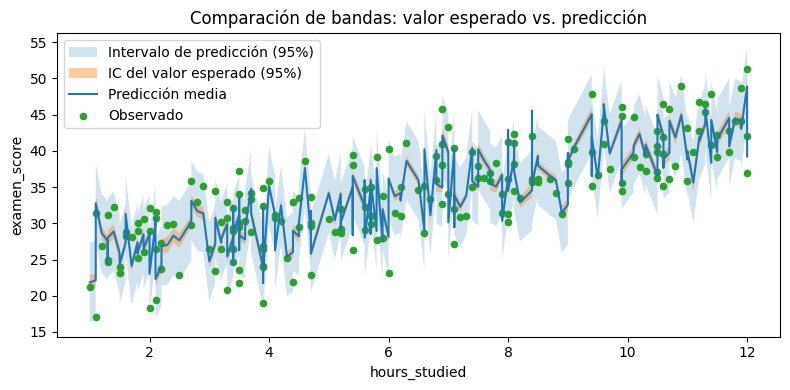

In [7]:

# Predicciones para todas las observaciones
pred_all = modelo.get_prediction(X).summary_frame(alpha=0.05).copy()

# Construimos un DataFrame auxiliar con hours_studied como eje horizontal
viz = pred_all.copy()
viz['hours_studied'] = X['hours_studied'].values
viz['y_obs'] = y.values
viz = viz.sort_values('hours_studied').reset_index(drop=True)

# Gráfico 1: bandas a lo largo del tiempo (YEAR)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

# Banda de intervalo de predicción (más ancha)
plt.fill_between(viz['hours_studied'], viz['obs_ci_lower'], viz['obs_ci_upper'], alpha=0.2, label='Intervalo de predicción (95%)')

# Banda de IC del valor esperado (más estrecha)
plt.fill_between(viz['hours_studied'], viz['mean_ci_lower'], viz['mean_ci_upper'], alpha=0.4, label='IC del valor esperado (95%)')

# Línea de la predicción media
plt.plot(viz['hours_studied'], viz['mean'], label='Predicción media')

# Observaciones reales
plt.scatter(viz['hours_studied'], viz['y_obs'], s=20, label='Observado')

plt.xlabel('hours_studied')
plt.ylabel('examen_score')
plt.title('Comparación de bandas: valor esperado vs. predicción')
plt.legend()
plt.tight_layout()
plt.show()
